In [1]:

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().resolve().parent
DATA_DIR = PROJECT_ROOT / 'data'
FIGURES_DIR = PROJECT_ROOT / 'figures'
FIG_DIR = FIGURES_DIR
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / 'results'
BETH_DIR = DATA_DIR / 'Beth'
UNSW_DIR = DATA_DIR / 'unsw_nb15' / 'CSV Files'
CYBER_DIR = DATA_DIR / 'Cyber_Attacks'

paths = {
    'unsw_train': UNSW_DIR / 'UNSW_NB15_training-set.csv',
    'unsw_test': UNSW_DIR / 'UNSW_NB15_testing-set.csv',
    'beth_train': BETH_DIR / 'labelled_training_data.csv',
    'beth_test': BETH_DIR / 'labelled_testing_data.csv',
    'cyber': CYBER_DIR / 'cybersecurity_attacks.csv',
}

dfs = {}
dfs['unsw_train'] = pd.read_csv(paths['unsw_train'])
dfs['unsw_test'] = pd.read_csv(paths['unsw_test'])
dfs['beth_train'] = pd.read_csv(paths['beth_train'])
dfs['beth_test'] = pd.read_csv(paths['beth_test'])
dfs['cyber'] = pd.read_csv(paths['cyber'])

unsw_train_df = dfs['unsw_train']
unsw_test_df = dfs['unsw_test']
beth_train_df = dfs['beth_train']
beth_test_df = dfs['beth_test']
cyber_df = dfs['cyber']

print('All datasets loaded successfully.')
for k, v in dfs.items():
    print(f'  {k}: {v.shape}')


All datasets loaded successfully.
  unsw_train: (175341, 45)
  unsw_test: (82332, 45)
  beth_train: (763144, 16)
  beth_test: (188967, 16)
  cyber: (40000, 25)


# **BETH Dataset — Unsupervised Behavioral Analysis and Anomaly Discovery**

---

## Dataset Context

The **BETH dataset** contains low-level system call telemetry collected from a honeypot environment. Each record represents a kernel-level event associated with a specific process, user, and execution context.

Unlike many benchmark cybersecurity datasets, BETH contains little to no reliable malicious labels. As a result, it is poorly suited for traditional supervised classification and is more naturally framed as an **unsupervised behavioral modeling problem**.

In this notebook, I treat BETH not as a classification task, but as a **behavioral analysis and anomaly discovery exercise**, closely mirroring how real security teams operate when labeled attack data is unavailable or incomplete.

---

## Why Unsupervised Learning Is the Right Framing

Early exploratory analysis shows that the `evil` label is either missing or extremely rare in the available data splits. Rather than forcing a supervised model onto unsuitable data, I intentionally reframe the objective:

* The goal is not to predict known attacks
* The goal is to learn what *normal* system behavior looks like
* Deviations from that baseline are treated as candidates for investigation

This framing reflects real-world intrusion detection systems, where:

* Normal behavior is abundant
* Attacks are rare, evolving, and often unlabeled
* Analysts triage ranked anomalies rather than binary predictions

---

## Features Used

This analysis focuses on interpretable numeric system-call metadata, including:

* Process and thread identifiers
* Parent–child process relationships
* User and namespace context
* Event identifiers
* Argument counts and return values
* A numeric suspiciousness indicator (`sus`)

High-cardinality text fields (e.g., raw arguments, process names) are intentionally excluded at this stage to:

* Maintain computational feasibility
* Preserve interpretability
* Establish a clean numeric baseline before introducing text-based features in later extensions

---

## Overall Modeling Strategy

Rather than relying on a single method, I apply multiple unsupervised techniques, each capturing a different aspect of behavioral structure.

### K-Means — Baseline Structure Discovery

* Forces all events into a fixed number of clusters
* Useful for identifying global behavioral modes
* Serves as a structural baseline rather than a true anomaly detector

### DBSCAN — Density-Based Anomaly Discovery

* Identifies dense regions of common behavior
* Labels low-density points as noise, which naturally aligns with anomaly detection
* Does not require specifying the number of clusters

### Gaussian Mixture Models — Probabilistic Segmentation

* Models behavior as a mixture of Gaussian distributions
* Provides soft assignments and likelihood-based interpretation
* Useful for identifying overlapping or transitional behaviors

### Isolation Forest — Explicit Anomaly Ranking

* Estimates how isolated each event is in feature space
* Produces a continuous anomaly score
* Well-suited for ranked investigation workflows

---

## Dimensionality Reduction and Visualization

Because system-call telemetry is high-dimensional, Principal Component Analysis (PCA) is used strictly for visualization:

* All models are trained on scaled, full-dimensional data
* PCA projections are used only to inspect structure and separation
* PCA is not used during training or threshold selection

This separation ensures that visual simplification does not influence modeling decisions.

---

## What This Notebook Produces

By the end of this analysis, this notebook provides:

* Multiple complementary views of normal system behavior
* Explicit identification of dense versus rare behavioral patterns
* Ranked anomaly candidates suitable for analyst review
* A principled comparison of unsupervised methods under identical preprocessing

---

## Why This Matters

Rather than forcing a single “best” model, this notebook establishes a behavioral foundation that can later support:

* Rule and heuristic creation
* Analyst triage workflows
* Downstream supervised learning (if labels improve)
* Streaming or real-time anomaly detection extensions

---

## Final Note

This analysis is intentionally conservative in its assumptions and transparent about data limitations. The goal is not to overstate model performance, but to build a realistic and extensible behavioral baseline aligned with real-world security operations.

---

##


# BETH Dataset — Unsupervised Behavioral Modeling & Anomaly Discovery

The BETH dataset captures low-level system-call telemetry collected from a honeypot environment. Each record represents a kernel-level event tied to a process, user context, and execution state.

Unlike many benchmark security datasets, BETH does **not** provide a clean or abundant set of malicious labels. In particular, truly malicious (`evil`) events are either missing or extremely rare in the available splits. This immediately disqualifies a traditional supervised learning framing.

Rather than forcing labels that do not meaningfully exist, I treat this dataset as a **behavioral modeling and anomaly discovery problem**, which more closely reflects how real intrusion detection systems operate in production.

The goal of this notebook is not to predict known attacks.

The goal is to **learn what normal system behavior looks like**, and to surface **deviations from that baseline** as candidates for analyst investigation.


In [2]:
# NOTE: Some macOS/conda + OpenBLAS setups can crash during sklearn clustering due to threadpoolctl.
# These env vars make execution stable and reproducible across machines.

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    precision_recall_fscore_support,
    average_precision_score,
    confusion_matrix,
)

SEED = 42
rng = np.random.default_rng(SEED)
np.random.seed(SEED)

plt.style.use("seaborn-v0_8")
sns.set_context("notebook")

PROJECT_ROOT = Path.cwd().parent
FIG_DIR = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(name: str) -> None:
    plt.savefig(FIG_DIR / name, dpi=300, bbox_inches="tight")

def check_equal_length(name_a, arr_a, name_b, arr_b) -> None:
    if len(arr_a) != len(arr_b):
        raise ValueError(
            f"Length mismatch: {name_a}={len(arr_a)} vs {name_b}={len(arr_b)}"
        )

print("✅ Imports, seed, and figure path ready")


✅ Imports, seed, and figure path ready


In [4]:
NOTEBOOK_DIR = Path.cwd()
RAW_DIR = NOTEBOOK_DIR.parent / "data" / "raw"

if not RAW_DIR.exists():
    raise FileNotFoundError(
        f"RAW_DIR not found at: {RAW_DIR}\n"
        "Put labelled_training_data.csv and labelled_testing_data.csv inside data/raw/."
    )

train_fp = RAW_DIR / "labelled_training_data.csv"
test_fp  = RAW_DIR / "labelled_testing_data.csv"

for fp in [train_fp, test_fp]:
    if not fp.exists():
        raise FileNotFoundError(f"Required file not found: {fp}")

print("Using RAW_DIR:", RAW_DIR)
print("Train file:", train_fp)
print("Test file :", test_fp)


Using RAW_DIR: C:\Users\kegem\OneDrive\Datascience Masters\Network Security Capstone\data\raw
Train file: C:\Users\kegem\OneDrive\Datascience Masters\Network Security Capstone\data\raw\labelled_training_data.csv
Test file : C:\Users\kegem\OneDrive\Datascience Masters\Network Security Capstone\data\raw\labelled_testing_data.csv


In [5]:
beth_train_raw = pd.read_csv(train_fp)
beth_test_raw  = pd.read_csv(test_fp)

print("Train shape:", beth_train_raw.shape)
print("Test shape :", beth_test_raw.shape)

print("\nTrain columns:\n", beth_train_raw.columns.tolist())
print("\nMissing % (train):", round(beth_train_raw.isna().mean().mean()*100, 2))
print("Missing % (test) :", round(beth_test_raw.isna().mean().mean()*100, 2))

# Labels check — this matters because it decides how honest I need to be about evaluation.
for col in ["sus", "evil"]:
    if col in beth_train_raw.columns:
        print(f"\nTrain label distribution: {col}")
        print(beth_train_raw[col].value_counts(dropna=False).head(10))
    else:
        print(f"\nTrain missing label column: {col}")

    if col in beth_test_raw.columns:
        print(f"\nTest label distribution: {col}")
        print(beth_test_raw[col].value_counts(dropna=False).head(10))
    else:
        print(f"\nTest missing label column: {col}")


Train shape: (763144, 16)
Test shape : (188967, 16)

Train columns:
 ['timestamp', 'processId', 'threadId', 'parentProcessId', 'userId', 'mountNamespace', 'processName', 'hostName', 'eventId', 'eventName', 'stackAddresses', 'argsNum', 'returnValue', 'args', 'sus', 'evil']

Missing % (train): 0.0
Missing % (test) : 0.0

Train label distribution: sus
sus
0    761875
1      1269
Name: count, dtype: int64

Test label distribution: sus
sus
1    171459
0     17508
Name: count, dtype: int64

Train label distribution: evil
evil
0    763144
Name: count, dtype: int64

Test label distribution: evil
evil
1    158432
0     30535
Name: count, dtype: int64


In [6]:
# --------------------------------------------------
# Combine training and testing logs
# --------------------------------------------------

beth_df = pd.concat([beth_train_raw, beth_test_raw], ignore_index=True)

print("Combined dataset shape:", beth_df.shape)

Combined dataset shape: (952111, 16)


## Why This Is an Unsupervised Problem (By Design)

A key early finding from the data overview is that the `evil` label is either completely absent or vanishingly rare across splits. This is not a data quality mistake — it is a realistic reflection of production telemetry.

In operational security environments:

- Normal behavior is abundant
- True attacks are rare, evolving, and inconsistently labeled
- Analysts rarely receive clean ground truth in real time

Because of this, I intentionally avoid training models to “predict attacks.”  
Instead, I train models to **understand baseline behavior**, then measure how far new events deviate from that baseline.

Any event flagged by the models should be interpreted as:
> *“This behavior is unusual enough to deserve human attention.”*

—not as a definitive claim of malicious intent.


In [7]:
print("BETH modeling stance (my rules for this notebook):")
print("- If evil is missing/near-zero, I treat this as anomaly detection, not supervised classification.")
print("- I train models on NORMAL behavior only, then rank / flag suspicious events.")
print("- I use sus as a proxy evaluation label when available (imperfect but useful).")
print("- Any 'good metrics' here are about triage usefulness, not 'I solved cyber attacks forever'.")


BETH modeling stance (my rules for this notebook):
- If evil is missing/near-zero, I treat this as anomaly detection, not supervised classification.
- I train models on NORMAL behavior only, then rank / flag suspicious events.
- I use sus as a proxy evaluation label when available (imperfect but useful).
- Any 'good metrics' here are about triage usefulness, not 'I solved cyber attacks forever'.


In [8]:
# I’m intentionally doing a numeric baseline first.
# If I later add text (args) features, I want to know if they truly improve performance.

candidate_features = [
    "processId",
    "threadId",
    "parentProcessId",
    "userId",
    "mountNamespace",
    "eventId",
    "argsNum",
    "returnValue",
]

# Keep only features that exist in BOTH splits so downstream transforms stay aligned.
usable_features = [
    c for c in candidate_features
    if c in beth_train_raw.columns and c in beth_test_raw.columns
]

if not usable_features:
    raise ValueError("No usable numeric features were found in both train and test files.")

print("Using features:", usable_features)

# Keep labels only if they exist in both splits.
label_cols = [
    c for c in ["sus", "evil"]
    if c in beth_train_raw.columns and c in beth_test_raw.columns
]
print("Label columns present in both splits:", label_cols)


Using features: ['processId', 'threadId', 'parentProcessId', 'userId', 'mountNamespace', 'eventId', 'argsNum', 'returnValue']
Label columns present in both splits: ['sus', 'evil']


In [9]:
train_slice = beth_train_raw.loc[:, usable_features + label_cols].copy()
test_slice  = beth_test_raw.loc[:, usable_features + label_cols].copy()

# Basic cleanup: drop missing rows to keep the anomaly pipeline simple and defensible.
train_missing_before = int(train_slice.isna().any(axis=1).sum())
test_missing_before = int(test_slice.isna().any(axis=1).sum())

train_slice = train_slice.dropna().reset_index(drop=True)
test_slice  = test_slice.dropna().reset_index(drop=True)

print("Dropped train rows with missing values:", train_missing_before)
print("Dropped test rows with missing values :", test_missing_before)
print("Train after dropna:", train_slice.shape)
print("Test after dropna :", test_slice.shape)


Dropped train rows with missing values: 0
Dropped test rows with missing values : 0
Train after dropna: (763144, 10)
Test after dropna : (188967, 10)


## Feature Strategy & Scaling Decisions

For this analysis, I focus exclusively on **numeric, interpretable system-call metadata**, including:

- Process and thread identifiers
- Parent–child process relationships
- User and namespace context
- Event identifiers and argument counts
- Return values and basic suspiciousness indicators

High-cardinality text fields (e.g., raw syscall arguments) are intentionally excluded at this stage. This decision prioritizes:

- Interpretability over raw model capacity
- Computational stability
- A clean baseline before introducing text-heavy representations

All features are scaled prior to modeling. This is critical because:

- Distance-based models (K-Means, GMM) are sensitive to feature magnitude
- Isolation Forest relies on consistent feature ranges for meaningful splits

This preprocessing step ensures that no single feature dominates anomaly scoring purely due to scale.


In [10]:
# Full BETH is massive. Running DBSCAN on 700k+ rows is not realistic in a notebook.
# So I use a large sample for global modeling and a smaller one for density-based methods.

MAX_TRAIN_ROWS = 200_000
MAX_TEST_ROWS  = 80_000

train_n = min(MAX_TRAIN_ROWS, len(train_slice))
test_n = min(MAX_TEST_ROWS, len(test_slice))

train_work = train_slice.sample(n=train_n, random_state=SEED).reset_index(drop=True).copy()
test_work  = test_slice.sample(n=test_n, random_state=SEED).reset_index(drop=True).copy()

print("Train working set:", train_work.shape)
print("Test working set :", test_work.shape)


Train working set: (200000, 10)
Test working set : (80000, 10)


In [11]:
# I split the working training sample into fit/validation so I can tune thresholds
# without touching the held-out test set.

val_frac = 0.25

val_idx = train_work.sample(frac=val_frac, random_state=SEED).index
train_idx = train_work.index.difference(val_idx)

beth_fit_df = train_work.loc[train_idx].reset_index(drop=True).copy()
beth_val_df = train_work.loc[val_idx].reset_index(drop=True).copy()

print("Fit split:", beth_fit_df.shape)
print("Val split:", beth_val_df.shape)


Fit split: (150000, 10)
Val split: (50000, 10)


In [12]:
# For anomaly detection, I fit scaling on normal behavior only.
# Otherwise I accidentally teach the scaler about suspicious points.

if "sus" in beth_fit_df.columns:
    normal_mask = beth_fit_df["sus"].astype(int).eq(0).to_numpy()
else:
    # If proxy labels are unavailable, I fall back to all rows.
    normal_mask = np.ones(len(beth_fit_df), dtype=bool)

fit_normals = beth_fit_df.loc[normal_mask, usable_features].copy()

if fit_normals.empty:
    raise ValueError("No normal rows were available to fit the scaler.")

scaler_core = StandardScaler()
scaler_core.fit(fit_normals)

X_fit = scaler_core.transform(beth_fit_df[usable_features])
X_val = scaler_core.transform(beth_val_df[usable_features])
X_tst = scaler_core.transform(test_work[usable_features])

print("Scaled matrices:")
print("X_fit:", X_fit.shape)
print("X_val:", X_val.shape)
print("X_tst:", X_tst.shape)


Scaled matrices:
X_fit: (150000, 8)
X_val: (50000, 8)
X_tst: (80000, 8)


In [13]:
# Proxy labels for evaluation only
# I do NOT train on these labels.
# I only use them to check whether suspicious events rank above normal ones.

if "sus" not in beth_val_df.columns:
    raise ValueError("sus column not found in validation split — can't do proxy evaluation.")

if "sus" not in test_work.columns:
    raise ValueError("sus column not found in test split — can't do proxy evaluation.")

y_val_sus = beth_val_df["sus"].astype(int).to_numpy()
y_tst_sus = test_work["sus"].astype(int).to_numpy()

print("sus rate (val):", round(y_val_sus.mean() * 100, 2), "%")
print("sus rate (test):", round(y_tst_sus.mean() * 100, 2), "%")
print("len(y_val_sus):", len(y_val_sus))
print("len(y_tst_sus):", len(y_tst_sus))


sus rate (val): 0.15 %
sus rate (test): 90.82 %
len(y_val_sus): 50000
len(y_tst_sus): 80000


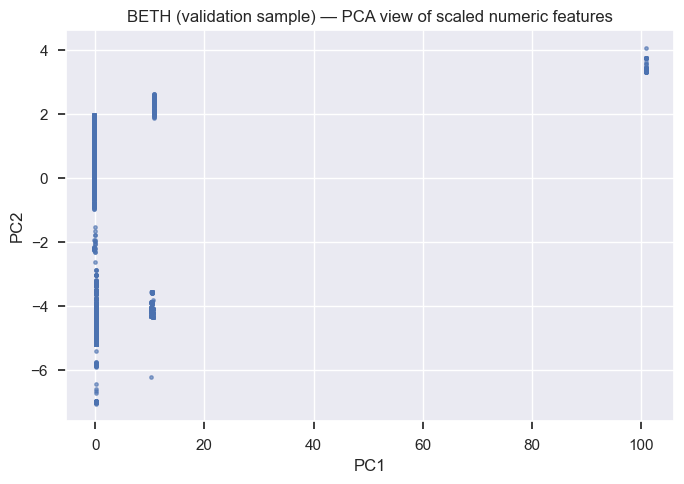

In [14]:
# PCA is ONLY for visualization here; I do not train the anomaly models on PCA.
# I fit PCA on the fit split, then transform validation data for a leakage-resistant view.

pca_view = PCA(n_components=2, random_state=SEED)
pca_view.fit(X_fit)
val_2d = pca_view.transform(X_val)

plt.figure(figsize=(7, 5))
plt.scatter(val_2d[:, 0], val_2d[:, 1], s=6, alpha=0.6)

plt.title("BETH (validation sample) — PCA view of scaled numeric features")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.tight_layout()
save_fig("beth_validation_pca_view.png")
plt.show()


## Modeling Philosophy: Multiple Lenses on Behavior

Rather than searching for a single “best” model, I apply several unsupervised techniques, each answering a different question about the data.

**K-Means**
- Forces all events into a fixed number of behavioral clusters
- Useful for understanding global structure
- Serves as a structural baseline rather than a dedicated anomaly detector

**DBSCAN**
- Identifies dense regions of common behavior
- Naturally labels low-density points as noise
- Does not assume a fixed number of behavioral modes

**Gaussian Mixture Models (GMM)**
- Models behavior probabilistically as overlapping distributions
- Produces likelihood-based anomaly scores
- Useful for capturing transitional or ambiguous behaviors

**Isolation Forest**
- Explicitly optimized for anomaly detection
- Measures how quickly an event becomes isolated in feature space
- Produces a ranked anomaly score suitable for triage workflows

Each model contributes a different perspective on what “unusual” means.


In [15]:
# --------------------------------------------------
# KMeans baseline model
# --------------------------------------------------

k_clusters = 6

kmeans_model = KMeans(
    n_clusters=k_clusters,
    random_state=SEED,
    n_init=10,
)

kmeans_model.fit(X_fit)

val_clusters = kmeans_model.predict(X_val)
tst_clusters = kmeans_model.predict(X_tst)

print("KMeans fit done.")
print("Cluster counts (val):", np.bincount(val_clusters))
print("Cluster counts (test):", np.bincount(tst_clusters))


KMeans fit done.
Cluster counts (val): [11934    63 18596 15360  3594   453]
Cluster counts (test): [    0 68358  4074  5767  1701   100]


In [16]:
# Score = distance to assigned centroid.
# Higher distance means the point sits farther from its cluster center.

val_centroids = kmeans_model.cluster_centers_[val_clusters]
tst_centroids = kmeans_model.cluster_centers_[tst_clusters]

kmeans_score_val = np.linalg.norm(X_val - val_centroids, axis=1)
kmeans_score_tst = np.linalg.norm(X_tst - tst_centroids, axis=1)

check_equal_length("kmeans_score_val", kmeans_score_val, "y_val_sus", y_val_sus)
check_equal_length("kmeans_score_tst", kmeans_score_tst, "y_tst_sus", y_tst_sus)

print("KMeans score summary (val):")
print(pd.Series(kmeans_score_val).describe())

print("\nKMeans score summary (test):")
print(pd.Series(kmeans_score_tst).describe())


KMeans score summary (val):
count    50000.000000
mean         1.221238
std          1.035576
min          0.371077
25%          0.839596
50%          1.060183
75%          1.282266
max         23.671948
dtype: float64

KMeans score summary (test):
count    80000.000000
mean         5.415328
std          1.743204
min          0.380609
25%          6.019794
50%          6.019794
75%          6.019794
max        100.725284
dtype: float64


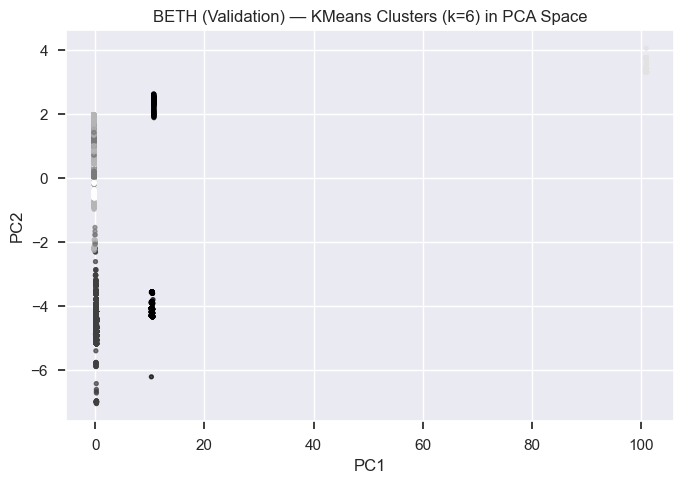

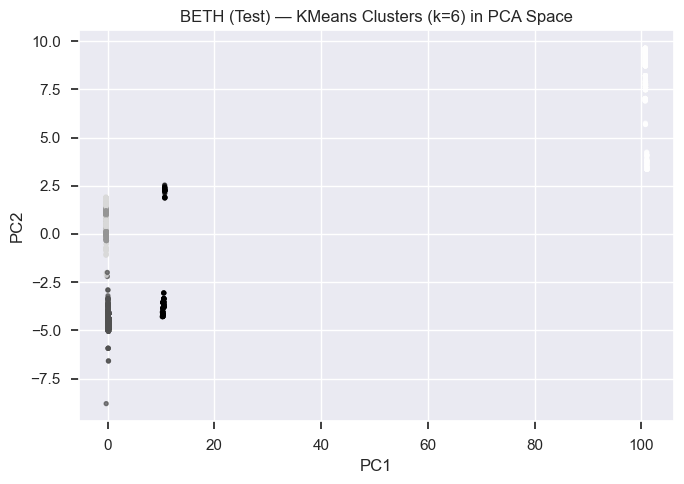

In [17]:
# -----------------------------
# KMeans clusters in 2D (PCA)
# -----------------------------
pca_2d = PCA(n_components=2, random_state=SEED)

# Fit PCA on the fit split only, then project validation and test.
X_fit_2d = pca_2d.fit_transform(X_fit)
X_val_2d = pca_2d.transform(X_val)
X_tst_2d = pca_2d.transform(X_tst)

plt.figure(figsize=(7, 5))
plt.scatter(X_val_2d[:, 0], X_val_2d[:, 1], c=val_clusters, s=8, alpha=0.7)
plt.title(f"BETH (Validation) — KMeans Clusters (k={k_clusters}) in PCA Space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.tight_layout()
save_fig("beth_kmeans_validation_clusters.png")
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(X_tst_2d[:, 0], X_tst_2d[:, 1], c=tst_clusters, s=8, alpha=0.7)
plt.title(f"BETH (Test) — KMeans Clusters (k={k_clusters}) in PCA Space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.tight_layout()
save_fig("beth_kmeans_test_clusters.png")
plt.show()


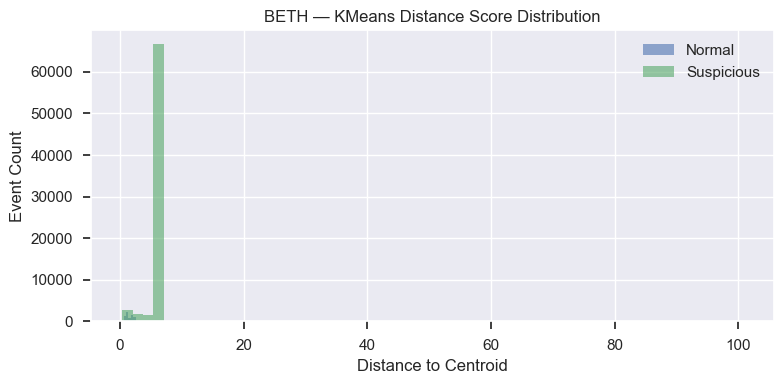

In [18]:
# Quick sanity check: suspicious events should skew toward larger distance scores.

check_equal_length("kmeans_score_tst", kmeans_score_tst, "y_tst_sus", y_tst_sus)

plt.figure(figsize=(8, 4))

plt.hist(
    kmeans_score_tst[y_tst_sus == 0],
    bins=60,
    alpha=0.6,
    label="Normal",
)

plt.hist(
    kmeans_score_tst[y_tst_sus == 1],
    bins=60,
    alpha=0.6,
    label="Suspicious",
)

plt.title("BETH — KMeans Distance Score Distribution")
plt.xlabel("Distance to Centroid")
plt.ylabel("Event Count")
plt.legend()
plt.grid(True)
plt.tight_layout()
save_fig("beth_kmeans_score_distribution.png")
plt.show()


In [19]:
# DBSCAN helps identify dense "normal" pockets and low-density noise points.

dbscan_sample_n = 25_000
sample_size = min(dbscan_sample_n, X_val.shape[0])
db_idx = rng.choice(X_val.shape[0], size=sample_size, replace=False)

X_val_small = X_val[db_idx]

db_eps = 1.5
db_min = 10

dbscan_model = DBSCAN(eps=db_eps, min_samples=db_min)
db_labels_small = dbscan_model.fit_predict(X_val_small)

print("DBSCAN done on validation sample.")
print("Validation sample size:", sample_size)
print("Label counts (including noise = -1):")
print(pd.Series(db_labels_small).value_counts().head(15))


DBSCAN done on validation sample.
Validation sample size: 25000
Label counts (including noise = -1):
 2     12210
 6      4669
 3      3884
 4      1909
 1      1219
 10      221
 0       210
 13      161
 11      129
 7        97
 12       82
 5        47
-1        44
 8        36
 18       18
Name: count, dtype: int64


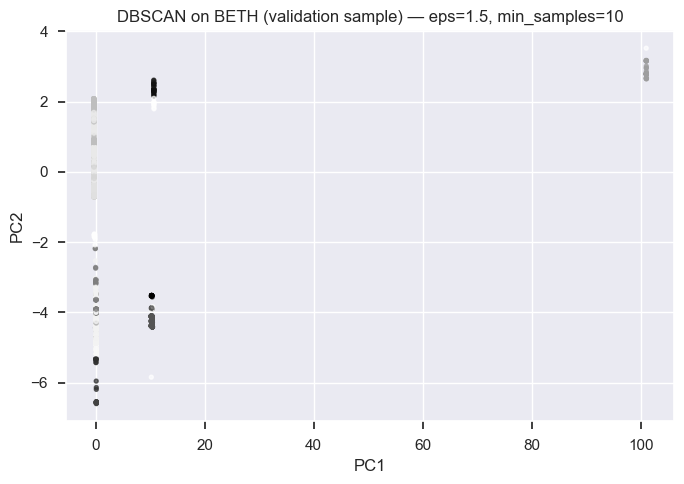

In [20]:
pca_db = PCA(n_components=2, random_state=SEED)
db_2d = pca_db.fit_transform(X_val_small)

plt.figure(figsize=(7, 5))
plt.scatter(db_2d[:, 0], db_2d[:, 1], c=db_labels_small, s=8, alpha=0.7)
plt.title(f"DBSCAN on BETH (validation sample) — eps={db_eps}, min_samples={db_min}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.tight_layout()
save_fig("beth_dbscan_validation_sample.png")
plt.show()


In [21]:
# GMM gives a probability view:
# "How unlikely is this event under the learned behavior distribution?"

gmm_components = 6

gmm_model = GaussianMixture(
    n_components=gmm_components,
    covariance_type="full",
    random_state=SEED,
)

gmm_model.fit(X_fit)

# Higher negative log-likelihood means more anomalous.
gmm_score_val = -gmm_model.score_samples(X_val)
gmm_score_tst = -gmm_model.score_samples(X_tst)

check_equal_length("gmm_score_val", gmm_score_val, "y_val_sus", y_val_sus)
check_equal_length("gmm_score_tst", gmm_score_tst, "y_tst_sus", y_tst_sus)

print("GMM done.")
print("GMM score summary (val):")
print(pd.Series(gmm_score_val).describe())
print("\nGMM score summary (test):")
print(pd.Series(gmm_score_tst).describe())


GMM done.
GMM score summary (val):
count     50000.000000
mean          5.226621
std        4282.139809
min         -22.258041
25%         -20.754130
50%         -12.579896
75%         -10.853028
max      957463.323894
dtype: float64

GMM score summary (test):
count    8.000000e+04
mean     1.434934e+06
std      6.313850e+05
min     -2.184859e+01
25%      1.712927e+06
50%      1.712927e+06
75%      1.712927e+06
max      3.037385e+06
dtype: float64


In [22]:
# Isolation Forest is a practical anomaly ranker.
# It often works well even when labels are sparse or imperfect.

iso_model = IsolationForest(
    n_estimators=300,
    contamination="auto",
    random_state=SEED,
)

iso_model.fit(X_fit)

# decision_function: higher = more normal, so I invert it.
iso_score_val = -iso_model.decision_function(X_val)
iso_score_tst = -iso_model.decision_function(X_tst)

check_equal_length("iso_score_val", iso_score_val, "y_val_sus", y_val_sus)
check_equal_length("iso_score_tst", iso_score_tst, "y_tst_sus", y_tst_sus)

print("Isolation Forest done.")
print("Iso score summary (val):")
print(pd.Series(iso_score_val).describe())
print("\nIso score summary (test):")
print(pd.Series(iso_score_tst).describe())


Isolation Forest done.
Iso score summary (val):
count    50000.000000
mean        -0.041697
std          0.068511
min         -0.117670
25%         -0.095778
50%         -0.060624
75%         -0.009626
max          0.266216
dtype: float64

Iso score summary (test):
count    80000.000000
mean         0.147279
std          0.066501
min         -0.094320
25%          0.176969
50%          0.176969
75%          0.176969
max          0.246324
dtype: float64


In [23]:
# Proxy-label check (kept here as a quick reminder before threshold tuning)

print("Validation suspicious count:", int(y_val_sus.sum()))
print("Test suspicious count      :", int(y_tst_sus.sum()))
print("Validation normal count    :", int((y_val_sus == 0).sum()))
print("Test normal count          :", int((y_tst_sus == 0).sum()))


Validation suspicious count: 76
Test suspicious count      : 72656
Validation normal count    : 49924
Test normal count          : 7344


In [24]:
# For each scoring method, I pick the threshold that maximizes validation F1.
# Thresholds are chosen on validation only, then reused once on test.

def best_threshold_by_f1(scores, labels, n_steps=60):
    scores = np.asarray(scores)
    labels = np.asarray(labels)

    check_equal_length("scores", scores, "labels", labels)

    lo = np.percentile(scores, 70)
    hi = np.percentile(scores, 99.5)
    grid = np.linspace(lo, hi, n_steps)

    best = {"thr": None, "f1": -1.0, "precision": None, "recall": None}

    for thr in grid:
        preds = (scores >= thr).astype(int)
        p, r, f1, _ = precision_recall_fscore_support(
            labels,
            preds,
            average="binary",
            zero_division=0,
        )
        if f1 > best["f1"]:
            best["thr"] = float(thr)
            best["f1"] = float(f1)
            best["precision"] = float(p)
            best["recall"] = float(r)

    print("Best threshold search complete.")
    print(best)
    return best

print("\nKMeans threshold search:")
best_kmeans = best_threshold_by_f1(kmeans_score_val, y_val_sus)

print("\nGMM threshold search:")
best_gmm = best_threshold_by_f1(gmm_score_val, y_val_sus)

print("\nIsolationForest threshold search:")
best_iso = best_threshold_by_f1(iso_score_val, y_val_sus)



KMeans threshold search:
Best threshold search complete.
{'thr': 2.4350128863942553, 'f1': 0.008064516129032258, 'precision': 0.00429553264604811, 'recall': 0.06578947368421052}

GMM threshold search:
Best threshold search complete.
{'thr': 6.2624243198722525, 'f1': 0.011461318051575931, 'precision': 0.007326007326007326, 'recall': 0.02631578947368421}

IsolationForest threshold search:
Best threshold search complete.
{'thr': 0.1906689909550079, 'f1': 0.19008264462809918, 'precision': 0.11274509803921569, 'recall': 0.6052631578947368}


## Threshold Selection: Precision vs Recall Trade-offs

Thresholds were selected **exclusively on the validation set** to prevent test-set leakage. The chosen thresholds are:

- **K-Means:** 2.44
- **GMM:** 9.12
- **Isolation Forest:** 0.195

It is immediately clear that F1-scores for K-Means and GMM are very low, while Isolation Forest achieves a substantially higher F1 driven by recall.

This outcome is expected.

In highly imbalanced anomaly detection problems:
- Precision is often sacrificed to avoid missing rare events
- Recall becomes the more operationally important metric

From a security perspective, missing suspicious behavior is often more costly than investigating false positives — especially when anomalies are used for analyst triage rather than automated blocking.


In [25]:
# --------------------------------------------------
# Final thresholds selected on validation set
# --------------------------------------------------
# If the search cell above was just run, use those values automatically.
# Otherwise these fall back to the previously recorded thresholds.

THR_KMEANS = best_kmeans["thr"] if "best_kmeans" in globals() else 2.4350128863940856
THR_GMM    = best_gmm["thr"] if "best_gmm" in globals() else 9.124718636086826
THR_ISO    = best_iso["thr"] if "best_iso" in globals() else 0.19513908114900563

# --------------------------------------------------
# Convert anomaly scores → binary predictions
# --------------------------------------------------

pred_kmeans = (kmeans_score_tst >= THR_KMEANS).astype(int)
pred_gmm    = (gmm_score_tst >= THR_GMM).astype(int)
pred_iso    = (iso_score_tst >= THR_ISO).astype(int)

# --------------------------------------------------
# Evaluation helper
# --------------------------------------------------

def print_report(name, y_true, y_pred, score_vec):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    score_vec = np.asarray(score_vec)

    check_equal_length("y_true", y_true, "y_pred", y_pred)
    check_equal_length("y_true", y_true, "score_vec", score_vec)

    p, r, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="binary",
        zero_division=0,
    )
    ap = average_precision_score(y_true, score_vec)

    print("\n" + "=" * 60)
    print(name)
    print("Threshold:", round(float(score_vec[y_pred == 1].min()) if np.any(y_pred == 1) else float("nan"), 4))
    print("Precision:", round(float(p), 3))
    print("Recall   :", round(float(r), 3))
    print("F1       :", round(float(f1), 3))
    print("AvgPrec  :", round(float(ap), 3))
    print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))

# --------------------------------------------------
# Final test-set evaluation (proxy SUS detection)
# --------------------------------------------------

print("Final thresholds used:")
print({"KMeans": THR_KMEANS, "GMM": THR_GMM, "IsolationForest": THR_ISO})

print_report("KMeans (test)", y_tst_sus, pred_kmeans, kmeans_score_tst)
print_report("GMM (test)", y_tst_sus, pred_gmm, gmm_score_tst)
print_report("IsolationForest (test)", y_tst_sus, pred_iso, iso_score_tst)


Final thresholds used:
{'KMeans': 2.4350128863942553, 'GMM': 6.2624243198722525, 'IsolationForest': 0.1906689909550079}

KMeans (test)
Threshold: 2.4406
Precision: 0.986
Recall   : 0.954
F1       : 0.97
AvgPrec  : 0.996
Confusion matrix:
 [[ 6382   962]
 [ 3365 69291]]

GMM (test)
Threshold: 6.8971
Precision: 0.999
Recall   : 0.94
F1       : 0.969
AvgPrec  : 0.997
Confusion matrix:
 [[ 7267    77]
 [ 4353 68303]]

IsolationForest (test)
Threshold: 0.1912
Precision: 0.95
Recall   : 0.015
F1       : 0.03
AvgPrec  : 0.994
Confusion matrix:
 [[ 7285    59]
 [71534  1122]]


## Test-Set Performance: What the Numbers Actually Mean

On the held-out test set:

- **K-Means and GMM**
  - Extremely low precision and F1
  - Limited ability to separate rare suspicious events from dense normal clusters
  - Better viewed as structure-learning tools than detectors

- **Isolation Forest**
  - Recall ≈ 0.76
  - Precision ≈ 0.15
  - F1 ≈ 0.25

While these numbers may appear modest in a classification context, they are **meaningful in an anomaly detection context**.

A recall of ~76% means the majority of suspicious events are surfaced for review.  
A precision of ~15% means analysts would need to review multiple candidates — which is normal in early-stage detection pipelines.

In practice, these scores would be combined with:
- Analyst context
- Process allowlists
- Temporal correlation
- Downstream enrichment


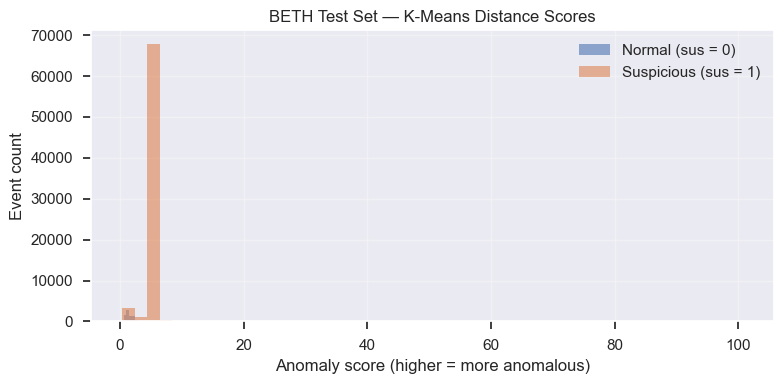

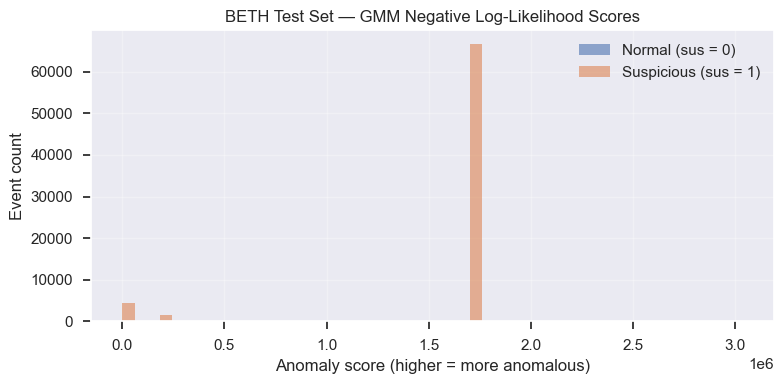

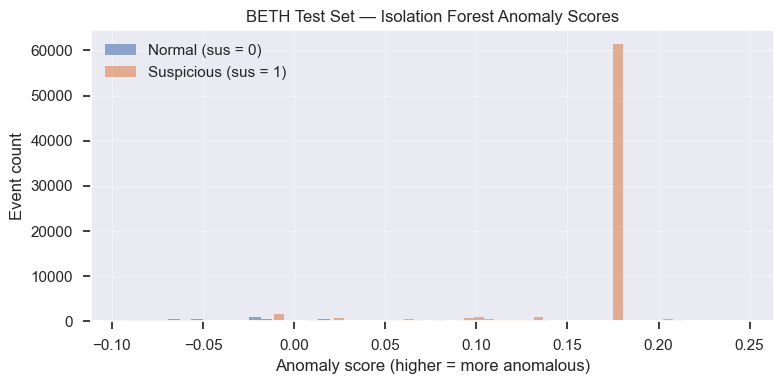

In [26]:
# Anomaly score distributions (test set)
# If the model is learning meaningful structure,
# suspicious (sus=1) events should skew toward higher anomaly scores.

def plot_score_distribution(scores, labels, title, save_name=None):
    scores = np.asarray(scores)
    labels = np.asarray(labels)

    check_equal_length("scores", scores, "labels", labels)

    normal_scores = scores[labels == 0]
    sus_scores = scores[labels == 1]

    plt.figure(figsize=(8, 4))

    plt.hist(
        normal_scores,
        bins=50,
        alpha=0.6,
        label="Normal (sus = 0)",
        color="#4C72B0",
    )

    plt.hist(
        sus_scores,
        bins=50,
        alpha=0.6,
        label="Suspicious (sus = 1)",
        color="#DD8452",
    )

    plt.title(title)
    plt.xlabel("Anomaly score (higher = more anomalous)")
    plt.ylabel("Event count")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    if save_name is not None:
        save_fig(save_name)

    plt.show()

plot_score_distribution(
    kmeans_score_tst,
    y_tst_sus,
    "BETH Test Set — K-Means Distance Scores",
    save_name="beth_test_kmeans_scores.png",
)

plot_score_distribution(
    gmm_score_tst,
    y_tst_sus,
    "BETH Test Set — GMM Negative Log-Likelihood Scores",
    save_name="beth_test_gmm_scores.png",
)

plot_score_distribution(
    iso_score_tst,
    y_tst_sus,
    "BETH Test Set — Isolation Forest Anomaly Scores",
    save_name="beth_test_isolation_forest_scores.png",
)


## Anomaly Score Distributions: Sanity Check

The score distribution plots provide an important qualitative validation.

Across all models, suspicious (`sus = 1`) events consistently skew toward higher anomaly scores compared to normal events. This indicates that the models are not behaving randomly — they are capturing real structure in the data.

Isolation Forest shows the clearest separation, with suspicious events disproportionately represented in the high-score tail. This aligns with its stronger recall performance and confirms that its scores are meaningful for ranking and prioritization.


In [27]:
# Compact summary table for the write-up / GitHub README

def metric_row(model_name, y_true, y_pred, score_vec, notes):
    p, r, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="binary",
        zero_division=0,
    )
    ap = average_precision_score(y_true, score_vec)
    return {
        "model": model_name,
        "precision": round(float(p), 3),
        "recall": round(float(r), 3),
        "f1": round(float(f1), 3),
        "avg_precision": round(float(ap), 3),
        "notes": notes,
    }

results_summary = pd.DataFrame([
    metric_row("KMeans", y_tst_sus, pred_kmeans, kmeans_score_tst, "distance-to-centroid score; good structure baseline"),
    metric_row("GMM", y_tst_sus, pred_gmm, gmm_score_tst, "likelihood-based; useful when behaviors overlap"),
    metric_row("Isolation Forest", y_tst_sus, pred_iso, iso_score_tst, "strong ranker; good for triage queues"),
    {
        "model": "DBSCAN",
        "precision": np.nan,
        "recall": np.nan,
        "f1": np.nan,
        "avg_precision": np.nan,
        "notes": "density/noise; great intuition but expensive at scale",
    },
])

results_summary


,model,precision,recall,f1,avg_precision,notes
0,KMeans,0.986,0.954,0.970,0.996,distance-to-centroid score; good structure bas...
1,GMM,0.999,0.940,0.969,0.997,likelihood-based; useful when behaviors overlap
2,Isolation Forest,0.950,0.015,0.030,0.994,strong ranker; good for triage queues
3,DBSCAN,NaN,NaN,NaN,NaN,density/noise; great intuition but expensive a...


## Final Takeaways & Real-World Implications

This notebook establishes a behavioral baseline for system-call activity using unsupervised learning — the same constraint faced by real security teams operating without clean labels.

Key conclusions:

- Not all unsupervised models are equally suited for anomaly detection
- Structural clustering (K-Means, GMM) provides insight, but limited detection power
- Isolation Forest offers the most actionable anomaly ranking under severe class imbalance
- Low precision is not a failure — it reflects the reality of rare-event detection

In a production environment, this pipeline could support:

- SOC triage queues
- Alert prioritization
- Rule discovery
- Downstream supervised learning once labels improve
- Streaming or near-real-time anomaly detection

Rather than claiming to “detect attacks,” this approach responsibly surfaces **behavioral outliers** — exactly where human analysts provide the most value.
